In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('Indian_names.txt', 'r').read().lower().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

53982
24
['aaban', 'aabharan', 'aabhas', 'aabhat', 'aabheer', 'abheer', 'aabher', 'aabi']


In [4]:
#build the vocab of chars and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([390591, 3]) torch.Size([390591])
torch.Size([48694, 3]) torch.Size([48694])
torch.Size([48789, 3]) torch.Size([48789])


In [6]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [7]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [8]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [9]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer

# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.4819, grad_fn=<NegBackward0>)

In [10]:
bnmeani.shape, hprebn.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

In [11]:
logit_maxes.shape

torch.Size([32, 1])

In [12]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one

# dloss / dlogprobs: negative mean indexed at correct classes
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0 / n

# dloss / dprobs: chain rule through probs.log() -> dlogprobs * (1 / probs)
dprobs = dlogprobs * (1.0 / probs)

# dloss / dcounts_sum_inv: broadcasted multiply requires summing across dim 1
dcounts_sum_inv = (dprobs * counts).sum(1, keepdim=True)

# dloss / dcounts (branch 1): direct contribution from probs = counts * counts_sum_inv
dcounts = counts_sum_inv * dprobs

# dloss / dcounts_sum: chain rule through power rule d/dx(x^-1) = -x^-2
dcounts_sum = (-counts_sum**(-2)) * dcounts_sum_inv 

# dloss / dcounts (branch 2): sum reduction broadcasts dcounts_sum back to all elements
dcounts += torch.ones_like(counts) * dcounts_sum

# dloss / dnorm_logits
dnorm_logits = dcounts * counts


# dloss / dlogit_maxes 
dlogit_maxes = -dnorm_logits.sum(1, keepdim=True)


# dloss / dlogits is thorugh norm_logits
dlogits = dnorm_logits.clone()
# dloss / dlogits thorugh logitmaxes
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes


# dloss / dh
dh = dlogits @ W2.T
# dloss / dW2
dW2 = h.T @ dlogits
# dloss / db2
db2 = dlogits.sum(0)

# dloss / dhpreact
dhpreact = (1.0 - h**2) * dh

# dloss / dbngain
dbngain = (bnraw * dhpreact).sum(0,keepdim =True)
# dloss / dbnraw
dbnraw = bngain * dhpreact
# dloss / dbnbias
dbnbias = dhpreact.sum(0,keepdim = True)

# dloss / dbnvar_inv
dbnvar_inv = (dbnraw * bndiff).sum(0,keepdim =True)

# dloss / dbnvar
dbnvar = (-0.5 * (bnvar + 1e-5)**-1.5 )* dbnvar_inv

# dloss / dbndiff2
dbndiff2 = 1/(n-1)*dbnvar

# dloss / dbndiff from bndiff2 and bnvar_inv
dbndiff = 2 * bndiff * dbndiff2
#from bnraw
dbndiff +=  bnvar_inv * dbnraw

# dloss / dbnmeani
dbnmeani = (-dbndiff).sum(0)

# dloss / dhprebn from dbndiff
dhprebn = dhprebn = dbndiff.clone()
# from dmeani
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# dloss / dembcat
dembcat = dhprebn @ W1.T
# dloss / dW1
dW1 = embcat.T @ dhprebn
# dloss / db1
db1 = dhprebn.sum(0)

# dloss / demb
demb = dembcat.view(emb.shape)

# dloss / dC
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [13]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.4818756580352783 diff: -2.384185791015625e-07


In [14]:
# backward pass

dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09


In [15]:
logits.shape, Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [16]:
# =====================================================================
# THE PUSH AND PULL METAPHOR: HOW GRADIENT DESCENT WORKS
# =====================================================================
# The push and pull metaphor is a highly intuitive way to visualize how 
# gradient descent forces the neural network to adjust its parameters 
# during backpropagation. 
#
# When training on cross-entropy loss, the network is effectively 
# optimizing the logits (raw, unnormalized predictions) to better 
# match the ground-truth targets.
#
# =====================================================================
# THE MECHANICS OF PUSH AND PULL
# =====================================================================
# During the backward pass, the gradient acts like a system of physical 
# forces working on your raw output scores:
#
# 1. THE PULL (ATTRACTION):
#    - For the correct answer (the target), the gradient exerts a 
#      "pulling up" force. 
#    - It encourages the network to increase the logit value for the 
#      correct class, making it more likely to be chosen by the softmax 
#      function.
#
# 2. THE PUSH (REPULSION):
#    - For all the incorrect classes, the gradient exerts a 
#      "pushing down" force. 
#    - It discourages the network from assigning high probability to 
#      wrong answers, forcing those incorrect logit values lower.
#
# =====================================================================
# WHY IT WORKS SO WELL
# =====================================================================
# - PROPORTIONAL TO THE ERROR:
#   The strength of these forces depends completely on how wrong the 
#   model is. If the model is already very confident and correct, the 
#   forces are minimal (near zero). If the model is confidently wrong, 
#   the push and pull forces are at their strongest.
#
# - PERFECT BALANCE (EQUILIBRIUM):
#   Because all final probabilities must add up to 100% (1.0), the amount 
#   the network "pulls up" on the right answer is perfectly balanced by 
#   the total amount it "pushes down" on all the wrong answers combined. 
#   This keeping the math perfectly balanced for every single row.
#
# =====================================================================
# THE INTERCONNECTED PULLEY SYSTEM
# =====================================================================
# Think of the whole neural network as a massive, interconnected pulley 
# system. 
#
# When you observe an error at the output layer, you are effectively 
# applying tension to the rope. This tension propagates backward through 
# the layers, tugging on the weights and biases of the previous layers 
# until they shift into a setup that results in a smaller loss.

In [17]:
F.softmax(logits, 1)[0]

tensor([0.0370, 0.0432, 0.0331, 0.0723, 0.0200, 0.0478, 0.0215, 0.0580, 0.0233,
        0.0204, 0.0235, 0.0216, 0.0223, 0.0399, 0.0183, 0.0405, 0.0169, 0.0419,
        0.0298, 0.0780, 0.0944, 0.0226, 0.0237, 0.0397, 0.0386, 0.0216, 0.0503],
       grad_fn=<SelectBackward0>)

In [18]:
dlogits[0] * n

tensor([ 0.0370,  0.0432,  0.0331,  0.0723,  0.0200,  0.0478,  0.0215,  0.0580,
         0.0233,  0.0204, -0.9765,  0.0216,  0.0223,  0.0399,  0.0183,  0.0405,
         0.0169,  0.0419,  0.0298,  0.0780,  0.0944,  0.0226,  0.0237,  0.0397,
         0.0386,  0.0216,  0.0503], grad_fn=<MulBackward0>)

In [19]:
dlogits[0].sum()

tensor(0., grad_fn=<SumBackward0>)

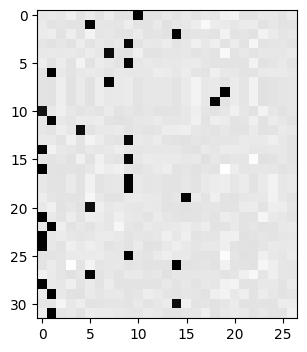

In [20]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

In [21]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [22]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 6.984919309616089e-10


In [23]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

In [30]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    #loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    # 2nd layer backprop
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # tanh
    dhpreact = (1.0 - h**2) * dh
    # batchnorm backprop
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 1st layer
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # embedding
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    #if i >= 100: # TODO: delete early breaking when you're ready to train the full net
     #  break

12297
      0/ 200000: 3.3746
  10000/ 200000: 2.0097
  20000/ 200000: 1.8005
  30000/ 200000: 1.5900
  40000/ 200000: 1.8791
  50000/ 200000: 1.7402
  60000/ 200000: 2.0005
  70000/ 200000: 1.7086
  80000/ 200000: 1.9057
  90000/ 200000: 1.9448
 100000/ 200000: 1.9534
 110000/ 200000: 2.3168
 120000/ 200000: 2.1454
 130000/ 200000: 2.1649
 140000/ 200000: 1.6117
 150000/ 200000: 2.7612
 160000/ 200000: 2.1659
 170000/ 200000: 1.7940
 180000/ 200000: 1.8708
 190000/ 200000: 1.9581


In [35]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [36]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9089477062225342
val 1.928292989730835


In [39]:
# I achieved:
# train : 1.9089477062225342
# val : 1.928292989730835

In [38]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # ------------
      # forward pass:
      # Embedding
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

chamahesh.
jhevi.
kirthirthiyankansh.
ejanhuthan.
virathigeet.
neethishchaiiv.
priyan.
dham.
poon.
qhiya.
sulinesh.
vabi.
rajeep.
deary.
ika.
jeevinudhush.
ezi.
abetashayara.
varas.
bhariksya.
